# Provisional hybrid accDM map: low-f q=1001 plus completed high-f q=5001

This notebook deliberately uses only the following sampled likelihoods:

- `f_acc <= 0.1`: completed fits from `accdm_scan_lowf_q1001_v2`;
- `f_acc > 0.1`: completed fits from `accdm_scan_highf_q5001_v1`.

High-fraction q=1001 scout fits are **not** used.  The sampled minimum and all
printed numerical values come only from genuinely completed fits.  Two
visualization policies are shown:

1. a conservative surface that leaves every missing expected coordinate white;
2. an edge-bracketed guide that interpolates between available q=5001 anchors,
   with every unsupported region explicitly hatched.

The second view is useful for judging possible topology, but it is not a
replacement for the missing q=5001/q=10001 calculations.



In [1]:
from pathlib import Path
import json
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator


def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "lyalpha_pt").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the lyalpha_one_loop project root.")


PROJECT_ROOT = find_project_root()
LOW_CAMPAIGN = PROJECT_ROOT / "runs/accdm/accdm_scan_lowf_q1001_v2"
HIGH_CAMPAIGN = PROJECT_ROOT / "runs/accdm/accdm_scan_highf_q5001_v1"
LOW_GRID_SPEC = PROJECT_ROOT / "campaigns/accdm/grid_specs/scan_lowf_boundary_q1001.json"
HIGH_GRID_SPEC = PROJECT_ROOT / "campaigns/accdm/grid_specs/scan_highf_boundary_q5001.json"
REFERENCE_FIT = PROJECT_ROOT / "results/lcdm_2022_planck_direct_k20_fit.json"

# Optional reproducibility mode for exported CSV products.  Leave unset on the
# cluster.  The high export may be either a direct q=5001 table or the overlap
# table written by notebook 03 (columns ending in _q5001).
LOW_EXPORT = os.environ.get("ACCDM_LOW_RESULTS_CSV")
HIGH_Q5001_EXPORT = os.environ.get("ACCDM_HIGH_Q5001_RESULTS_CSV")

OUTPUT_DIR = PROJECT_ROOT / "runs/accdm/analysis_hybrid_q1001_q5001_v1"
SAVE_OUTPUTS = os.environ.get("ACCDM_SAVE_OUTPUTS", "1").strip().lower() not in {
    "0", "false", "no",
}
T_REFERENCE_GYR = 14.0

DELTA_CHI2_68_2D = 2.30
DELTA_CHI2_95_2D = 5.991
EXCLUSION_DELTA_CHI2 = 3.841
DISPLAY_DELTA_MAX = 20.0
FALLBACK_LCDM_CHI2 = 193.105787

if REFERENCE_FIT.is_file():
    reference_payload = json.loads(REFERENCE_FIT.read_text(encoding="utf-8"))
    LCDM_ONE_LOOP_CHI2 = float(reference_payload["fits"]["one_loop"]["chi2"])
else:
    LCDM_ONE_LOOP_CHI2 = FALLBACK_LCDM_CHI2
    warnings.warn(f"Using fallback LCDM chi2={FALLBACK_LCDM_CHI2}.")

print("Project root        :", PROJECT_ROOT)
print("Low-f q=1001       :", LOW_CAMPAIGN)
print("High-f q=5001      :", HIGH_CAMPAIGN)
print("LCDM one-loop chi2 :", LCDM_ONE_LOOP_CHI2)
print("Output directory   :", OUTPUT_DIR)



Project root        : /home/2/ks405818/Master/lyalpha_one_loop
Low-f q=1001       : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_lowf_q1001_v2
High-f q=5001      : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_highf_q5001_v1
LCDM one-loop chi2 : 193.19661059914853
Output directory   : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_hybrid_q1001_q5001_v1


## Effective DCDM coordinates

The accDM energy-gain parameter is

\[
\eta = \frac{10^{11}\,{\rm GeV}}{m_{\rm acc}},\qquad
\frac{p}{m}=u=\sqrt{\eta(\eta+2)}.
\]

For two-body DCDM with one massless and one massive daughter,
\(\epsilon=(1-m^2/M^2)/2\) and
\(p/m=\epsilon/\sqrt{1-2\epsilon}\).  Matching the daughter momentum gives

\[
\epsilon_{\rm eff}
=\frac{u}{\sqrt{1+u^2}+u}.
\]

There is no exact one-to-one conversion between `f_acc` and the DCDM decay
rate: `f_acc` is the abundance assigned to the accelerating component, while
DCDM normally lets the mother population decay exponentially.  For plotting
only, define an effective rate by matching the converted fraction at a
configurable reference time:

\[
f_{\rm acc}=1-e^{-\Gamma_{\rm eff}t_{\rm ref}},\qquad
\Gamma_{\rm eff}=-\frac{\ln(1-f_{\rm acc})}{t_{\rm ref}}.
\]

We use \(t_{\rm ref}=14\,\mathrm{Gyr}\).  These are explicitly labelled
*effective DCDM coordinates*.  The `f_acc=1` edge maps to infinite rate and
is omitted from finite transformed plots.  The older quantity
`-t_ref*ln(f_acc)` is neither a decay rate nor a lifetime and is not used.



In [2]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def recoil_ratio_from_eta(eta):
    eta = np.asarray(eta, dtype=float)
    return np.sqrt(eta * (eta + 2.0))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = recoil_ratio_from_eta(eta)
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


def log10_effective_coordinates(log10m_acc, log10f_acc):
    epsilon = epsilon_effective_from_log10_mass(log10m_acc)
    gamma = gamma_effective_from_log10_fraction(log10f_acc)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.log10(epsilon), np.log10(gamma)


# Algebraic self-checks for both transformations.
test_logm = np.linspace(11.0, 18.0, 31)
test_eta = eta_from_log10_mass(test_logm)
test_recoil = recoil_ratio_from_eta(test_eta)
test_epsilon = epsilon_effective_from_log10_mass(test_logm)
reconstructed_recoil = test_epsilon / np.sqrt(1.0 - 2.0 * test_epsilon)
np.testing.assert_allclose(reconstructed_recoil, test_recoil, rtol=2e-13, atol=1e-15)

test_logf = np.linspace(-4.0, -0.1, 31)
test_fraction = 10.0**test_logf
test_gamma = gamma_effective_from_log10_fraction(test_logf)
reconstructed_fraction = -np.expm1(-test_gamma * T_REFERENCE_GYR)
np.testing.assert_allclose(reconstructed_fraction, test_fraction, rtol=2e-13, atol=1e-15)

print("epsilon_eff range over log10m=11..18:", test_epsilon.min(), "..", test_epsilon.max())
print("Gamma_eff [Gyr^-1] for f=1e-4..10^-0.1:", test_gamma.min(), "..", test_gamma.max())



epsilon_eff range over log10m=11..18: 0.00044701365139165834 .. 0.4641016151377546
Gamma_eff [Gyr^-1] for f=1e-4..10^-0.1: 7.1432143095255956e-06 .. 0.1129624109577467


## Load expected grids and completed fits



In [3]:
def active_mask(frame):
    if "active" not in frame:
        return np.ones(len(frame), dtype=bool)
    return frame["active"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def coordinate_key(logm, logf):
    return f"{float(logm):.10f}|{float(logf):.10f}"


def expected_from_grid_spec(path, region_label):
    payload = json.loads(path.read_text(encoding="utf-8"))
    axes = payload["axes"]
    rows = []
    for logf in axes["log10f_acc"]:
        for logm in axes["log10m_acc"]:
            rows.append({
                "coordinate_key": coordinate_key(logm, logf),
                "log10m_acc": float(logm),
                "log10f_acc": float(logf),
                "expected_region": region_label,
            })
    return pd.DataFrame(rows)


def fit_summary(path):
    payload = json.loads(path.read_text(encoding="utf-8"))
    fit = payload.get("fits", {}).get("one_loop")
    if fit is None:
        return None
    diagnostics = fit.get("boundary_diagnostics", [])
    nearest = None
    if diagnostics:
        nearest = min(
            diagnostics,
            key=lambda item: float(item["relative_distance_to_nearest_bound"]),
        )
    row = {
        "chi2_one_loop": float(fit["chi2"]),
        "chi2_per_dof": float(fit.get("chi2_per_dof", np.nan)),
        "optimizer_success": bool(fit.get("optimizer_success", False)),
        "minimum_bound_distance": (
            float(nearest["relative_distance_to_nearest_bound"])
            if nearest is not None else np.nan
        ),
        "minimum_bound_parameter": nearest["parameter"] if nearest is not None else None,
    }
    for name, value in fit.get("parameters", {}).items():
        row[f"parameter_{name}"] = float(value)
    return row


def load_live_campaign(directory, source_label, momentum_bins):
    manifest_path = directory / "manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing campaign manifest: {manifest_path}")
    manifest = pd.read_csv(manifest_path)
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    for record in manifest.to_dict(orient="records"):
        point_id = str(record["point_id"])
        fit_path = directory / "fits" / f"{point_id}.json"
        row = {
            **record,
            "coordinate_key": coordinate_key(record["log10m_acc"], record["log10f_acc"]),
            "source_label": source_label,
            "momentum_bins": int(momentum_bins),
            "fit_path": str(fit_path),
            "theory_complete": (directory / "theory" / f"{point_id}.npz").is_file(),
            "theory_failed": (
                directory / "status/theory" / f"{point_id}.failed.json"
            ).is_file(),
            "chi2_one_loop": np.nan,
        }
        if fit_path.is_file():
            summary = fit_summary(fit_path)
            if summary is not None:
                row.update(summary)
        rows.append(row)
    frame = pd.DataFrame(rows)
    return frame, frame.loc[np.isfinite(frame["chi2_one_loop"])].copy()


def canonical_export(frame, source_label, momentum_bins, suffix=""):
    def source_column(name):
        candidate = f"{name}{suffix}"
        if candidate in frame:
            return candidate
        if name in frame:
            return name
        return None

    result = pd.DataFrame(index=frame.index)
    for name in (
        "point_id", "log10m_acc", "log10f_acc", "chi2_one_loop",
        "chi2_per_dof", "optimizer_success", "minimum_bound_distance",
        "minimum_bound_parameter",
    ):
        column = source_column(name)
        if column is not None:
            result[name] = frame[column]
    for column in frame.columns:
        if suffix and column.startswith("parameter_") and column.endswith(suffix):
            result[column[: -len(suffix)]] = frame[column]
        elif not suffix and column.startswith("parameter_"):
            result[column] = frame[column]
    required = {"log10m_acc", "log10f_acc", "chi2_one_loop"}
    missing_columns = required.difference(result.columns)
    if missing_columns:
        raise RuntimeError(f"Export is missing columns: {sorted(missing_columns)}")
    if "point_id" not in result:
        result["point_id"] = [
            f"export_{coordinate_key(logm, logf)}"
            for logm, logf in zip(result["log10m_acc"], result["log10f_acc"])
        ]
    result["coordinate_key"] = [
        coordinate_key(logm, logf)
        for logm, logf in zip(result["log10m_acc"], result["log10f_acc"])
    ]
    result["source_label"] = source_label
    result["momentum_bins"] = int(momentum_bins)
    result["theory_complete"] = True
    result["theory_failed"] = False
    result["chi2_one_loop"] = pd.to_numeric(result["chi2_one_loop"], errors="coerce")
    result = result.loc[np.isfinite(result["chi2_one_loop"])].copy()
    return result


def load_low_source():
    if LOW_EXPORT:
        raw = pd.read_csv(Path(LOW_EXPORT))
        if "source_label" in raw:
            raw = raw.loc[raw["source_label"].astype(str) == "low_q1001"].copy()
        fits = canonical_export(raw, "low_q1001", 1001)
        return fits.copy(), fits
    return load_live_campaign(LOW_CAMPAIGN, "low_q1001", 1001)


def load_high_source():
    if HIGH_Q5001_EXPORT:
        raw = pd.read_csv(Path(HIGH_Q5001_EXPORT))
        suffix = "_q5001" if "chi2_one_loop_q5001" in raw else ""
        fits = canonical_export(raw, "high_q5001", 5001, suffix=suffix)
        return fits.copy(), fits
    return load_live_campaign(HIGH_CAMPAIGN, "high_q5001", 5001)


expected_low = expected_from_grid_spec(LOW_GRID_SPEC, "low_q1001_expected")
expected_high = expected_from_grid_spec(HIGH_GRID_SPEC, "high_q5001_expected")
expected = pd.concat([expected_low, expected_high], ignore_index=True)
if expected["coordinate_key"].duplicated().any():
    raise RuntimeError("The expected low- and high-fraction grids overlap.")

low_status, low_fits = load_low_source()
high_status, high_fits = load_high_source()
low_fits = low_fits.loc[low_fits["log10f_acc"] <= -1.0 + 1e-12].copy()
high_fits = high_fits.loc[high_fits["log10f_acc"] > -1.0 + 1e-12].copy()

if not (low_fits["momentum_bins"] == 1001).all():
    raise RuntimeError("Low-fraction selection contains a non-q=1001 fit.")
if not (high_fits["momentum_bins"] == 5001).all():
    raise RuntimeError("High-fraction selection contains a non-q=5001 fit.")

selected = pd.concat([low_fits, high_fits], ignore_index=True, sort=False)
selected = selected.sort_values(["coordinate_key", "momentum_bins"])
if selected["coordinate_key"].duplicated().any():
    duplicates = selected.loc[selected["coordinate_key"].duplicated(False)]
    raise RuntimeError(f"Duplicate selected coordinates:\n{duplicates}")

hybrid = expected.merge(
    selected.drop(columns=["log10m_acc", "log10f_acc"], errors="ignore"),
    on="coordinate_key", how="left", validate="one_to_one",
)
completed = hybrid.loc[np.isfinite(hybrid["chi2_one_loop"])].copy()
missing = hybrid.loc[~np.isfinite(hybrid["chi2_one_loop"])].copy()

source_counts = completed.groupby(["source_label", "momentum_bins"]).size().rename("completed_fits")
print("\nSelected source counts")
print(source_counts.to_string())
print("\nExpected points :", len(expected))
print("Completed points:", len(completed))
print("Missing points  :", len(missing))
print("Low q=1001 fits :", len(low_fits))
print("High q=5001 fits:", len(high_fits))
if len(high_fits) != 99:
    warnings.warn(
        f"Found {len(high_fits)} completed high-f q=5001 fits; the reference snapshot had 99."
    )




Selected source counts
source_label  momentum_bins
high_q5001    5001.0            99
low_q1001     1001.0           843

Expected points : 1450
Completed points: 942
Missing points  : 508
Low q=1001 fits : 843
High q=5001 fits: 99


## Sampled hybrid likelihood and coverage



In [4]:
completed["delta_chi2_from_hybrid_minimum"] = (
    completed["chi2_one_loop"] - completed["chi2_one_loop"].min()
)
completed["delta_chi2_vs_lcdm"] = completed["chi2_one_loop"] - LCDM_ONE_LOOP_CHI2
completed["inside_hybrid_68pct"] = (
    completed["delta_chi2_from_hybrid_minimum"] <= DELTA_CHI2_68_2D
)
completed["inside_hybrid_95pct"] = (
    completed["delta_chi2_from_hybrid_minimum"] <= DELTA_CHI2_95_2D
)
best = completed.loc[completed["chi2_one_loop"].idxmin()]

print("\nSampled hybrid minimum")
print("  point_id          =", best.get("point_id", best["coordinate_key"]))
print(f"  log10(m_acc/GeV)  = {best['log10m_acc']:.10g}")
print(f"  log10(f_acc)      = {best['log10f_acc']:.10g}")
print(f"  f_acc             = {10**best['log10f_acc']:.10g}")
print(f"  chi2              = {best['chi2_one_loop']:.9f}")
print(f"  Delta chi2 LCDM   = {best['delta_chi2_vs_lcdm']:+.9f}")
print(f"  source            = {best['source_label']} (q={int(best['momentum_bins'])})")

summary_columns = [
    "point_id", "log10m_acc", "log10f_acc", "source_label", "momentum_bins",
    "chi2_one_loop", "delta_chi2_from_hybrid_minimum", "delta_chi2_vs_lcdm",
    "minimum_bound_parameter", "minimum_bound_distance",
]
summary_columns = [column for column in summary_columns if column in completed]
print("\nTwenty smallest sampled chi2 values")
print(completed.nsmallest(20, "chi2_one_loop")[summary_columns].to_string(index=False))




Sampled hybrid minimum
  point_id          = accdm_logm15p7142857142857_logfm1p3
  log10(m_acc/GeV)  = 15.71428571
  log10(f_acc)      = -1.3
  f_acc             = 0.05011872336
  chi2              = 188.986412635
  Delta chi2 LCDM   = -4.210197964
  source            = low_q1001 (q=1001)

Twenty smallest sampled chi2 values
                             point_id  log10m_acc  log10f_acc source_label  momentum_bins  chi2_one_loop  delta_chi2_from_hybrid_minimum  delta_chi2_vs_lcdm minimum_bound_parameter  minimum_bound_distance
  accdm_logm15p7142857142857_logfm1p3   15.714286      -1.300    low_q1001         1001.0     188.986413                        0.000000           -4.210198                 beta_ct                0.267960
accdm_logm15p7142857142857_logfm1p225   15.714286      -1.225    low_q1001         1001.0     189.033078                        0.046666           -4.163532                 beta_ct                0.260682
  accdm_logm15p8571428571429_logfm1p3   15.857143      -1

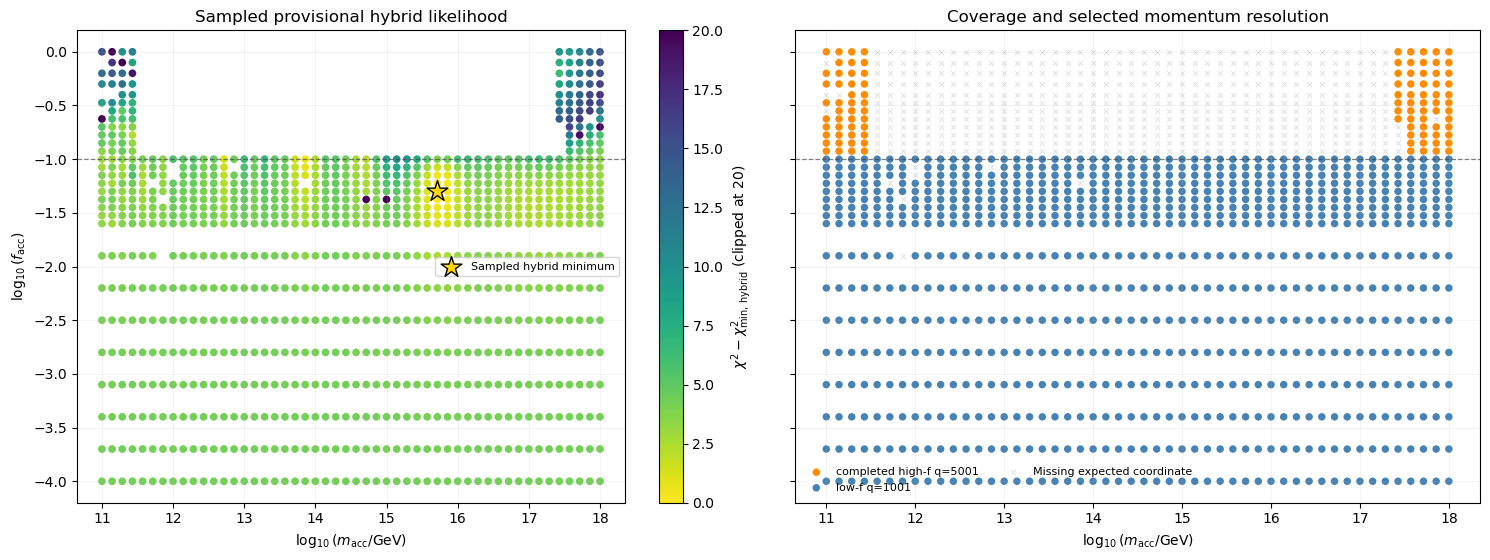

In [5]:
fig_coverage, axes = plt.subplots(1, 2, figsize=(15.0, 5.7), sharex=True, sharey=True)

sampled = axes[0].scatter(
    completed["log10m_acc"], completed["log10f_acc"],
    c=np.clip(completed["delta_chi2_from_hybrid_minimum"], 0, DISPLAY_DELTA_MAX),
    cmap="viridis_r", s=31, edgecolor="none", rasterized=True,
)
fig_coverage.colorbar(
    sampled, ax=axes[0],
    label=r"$\chi^2-\chi^2_{\min,\,\mathrm{hybrid}}$ (clipped at 20)",
)
axes[0].scatter(
    [best["log10m_acc"]], [best["log10f_acc"]], marker="*", s=245,
    color="gold", edgecolor="black", label="Sampled hybrid minimum", zorder=6,
)
axes[0].set_title("Sampled provisional hybrid likelihood")
axes[0].legend(frameon=True, fontsize=8)

source_styles = {
    "low_q1001": ("steelblue", "low-f q=1001"),
    "high_q5001": ("darkorange", "completed high-f q=5001"),
}
for label, group in completed.groupby("source_label"):
    color, legend_label = source_styles.get(label, ("gray", str(label)))
    axes[1].scatter(
        group["log10m_acc"], group["log10f_acc"], s=29,
        color=color, edgecolor="none", label=legend_label, rasterized=True,
    )
axes[1].scatter(
    missing["log10m_acc"], missing["log10f_acc"], marker="x", s=12,
    color="0.55", alpha=0.32, linewidth=0.6, label="Missing expected coordinate",
    rasterized=True,
)
axes[1].set_title("Coverage and selected momentum resolution")
axes[1].legend(frameon=False, fontsize=8, ncol=2)

for axis in axes:
    axis.axhline(-1.0, color="0.25", ls="--", lw=0.9, alpha=0.65)
    axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axis.grid(alpha=0.15)
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
fig_coverage.tight_layout()
plt.show()



## Conservative and edge-bracketed interpolation

The same linear interpolator is used in both views.  The conservative mask
hides pixels whose nearest expected grid coordinate has no fit.  The
edge-bracketed guide keeps the interpolation inside the convex hull of all
sampled points; its unsupported part is hatched.



In [6]:
def interpolated_surfaces(column, nx=700, ny=560):
    x_dense = np.linspace(expected["log10m_acc"].min(), expected["log10m_acc"].max(), nx)
    y_dense = np.linspace(expected["log10f_acc"].min(), expected["log10f_acc"].max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)

    x_scale = float(expected["log10m_acc"].max() - expected["log10m_acc"].min())
    y_scale = float(expected["log10f_acc"].max() - expected["log10f_acc"].min())
    sampled_coordinates = np.column_stack([
        completed["log10m_acc"] / x_scale,
        completed["log10f_acc"] / y_scale,
    ])
    dense_coordinates = np.column_stack([
        xx.ravel() / x_scale,
        yy.ravel() / y_scale,
    ])
    interpolator = LinearNDInterpolator(
        sampled_coordinates,
        completed[column].to_numpy(dtype=float),
        fill_value=np.nan,
    )
    raw_surface = interpolator(dense_coordinates).reshape(xx.shape)

    availability_table = hybrid[["log10m_acc", "log10f_acc", "chi2_one_loop"]].copy()
    availability = np.isfinite(availability_table["chi2_one_loop"]).astype(float)
    expected_coordinates = np.column_stack([
        availability_table["log10m_acc"] / x_scale,
        availability_table["log10f_acc"] / y_scale,
    ])
    nearest_availability = NearestNDInterpolator(
        expected_coordinates, availability.to_numpy(dtype=float),
    )(dense_coordinates).reshape(xx.shape)

    finite = np.isfinite(raw_surface)
    conservative = np.ma.array(raw_surface, mask=(~finite) | (nearest_availability < 0.5))
    bracketed = np.ma.array(raw_surface, mask=~finite)
    unsupported = finite & (nearest_availability < 0.5)
    return x_dense, y_dense, conservative, bracketed, unsupported


x_dense, y_dense, delta_min_conservative, delta_min_bracketed, unsupported = (
    interpolated_surfaces("delta_chi2_from_hybrid_minimum")
)
_, _, delta_lcdm_conservative, delta_lcdm_bracketed, _ = interpolated_surfaces(
    "delta_chi2_vs_lcdm"
)

finite_bracketed = np.isfinite(delta_min_bracketed.filled(np.nan))
print("Dense pixels inside sampled convex hull:", int(finite_bracketed.sum()))
print("Unsupported but edge-bracketed pixels  :", int(unsupported.sum()))
print(
    "Unsupported fraction of convex hull    :",
    float(unsupported.sum() / max(finite_bracketed.sum(), 1)),
)


def draw_profile_pair(
    x, y, conservative, bracketed, unsupported_mask,
    points_x, points_y, best_x, best_y, xlabel, ylabel, title_prefix,
):
    fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.9), sharex=True, sharey=True)
    surfaces = [conservative, bracketed]
    titles = [
        f"{title_prefix}: conservative missing-cell mask",
        f"{title_prefix}: edge-bracketed visual guide",
    ]
    for index, (axis, surface, title) in enumerate(zip(axes, surfaces, titles)):
        plotted = axis.contourf(
            x, y, np.clip(surface, 0, DISPLAY_DELTA_MAX),
            levels=np.linspace(0, DISPLAY_DELTA_MAX, 21),
            cmap="viridis_r", extend="max",
        )
        axis.contour(
            x, y, surface, levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
            colors=["white", "navy"], linewidths=[1.4, 2.0],
        )
        axis.scatter(points_x, points_y, s=3, color="black", alpha=0.18, rasterized=True)
        axis.scatter(
            [best_x], [best_y], marker="*", s=235, color="black",
            edgecolor="white", linewidth=0.8, zorder=6,
        )
        if index == 1 and np.any(unsupported_mask):
            axis.contourf(
                x, y, unsupported_mask.astype(float), levels=[0.5, 1.5],
                colors="none", hatches=["///"], alpha=0,
            )
            axis.legend(
                handles=[Patch(facecolor="none", edgecolor="0.35", hatch="///",
                               label="No fitted grid point; visual interpolation")],
                loc="best", frameon=True, fontsize=8,
            )
        axis.set_title(title)
        axis.set_xlabel(xlabel)
        axis.grid(alpha=0.12)
        fig.colorbar(plotted, ax=axis, label=r"$\chi^2-\chi^2_{\min,\,\mathrm{hybrid}}$")
    axes[0].set_ylabel(ylabel)
    fig.tight_layout()
    return fig



Dense pixels inside sampled convex hull: 392000
Unsupported but edge-bracketed pixels  : 81729
Unsupported fraction of convex hull    : 0.2084923469387755


## Map in native accDM coordinates



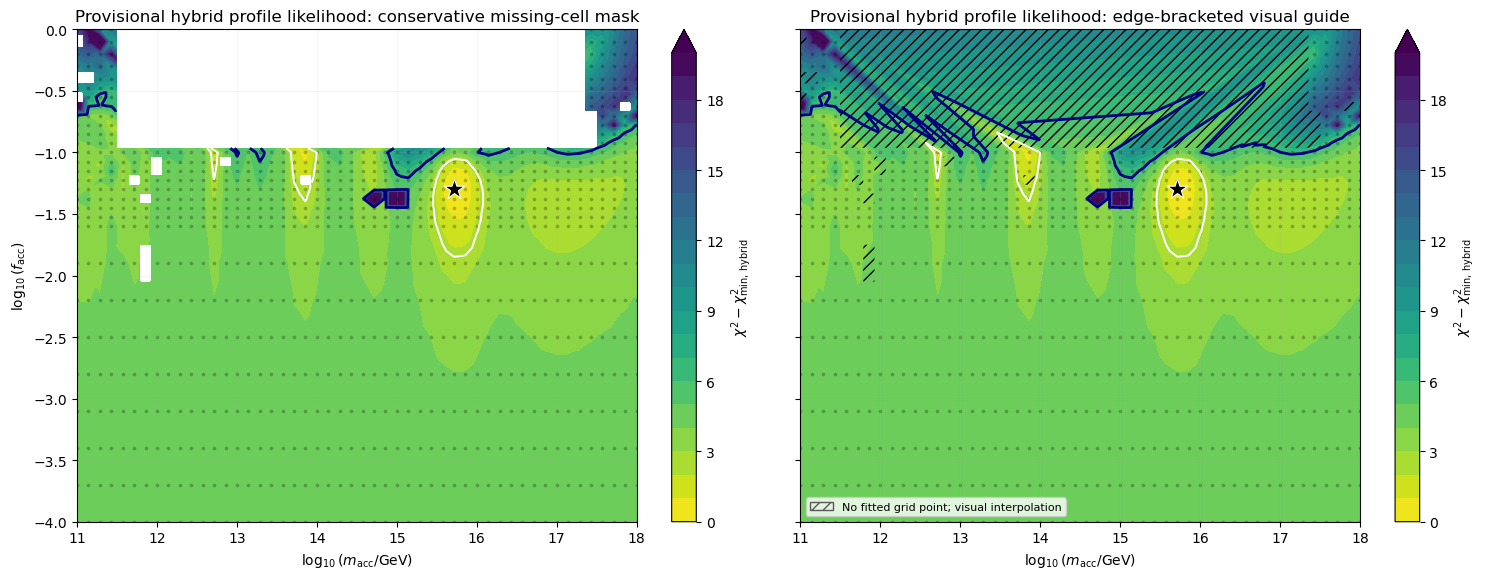

In [7]:
fig_native = draw_profile_pair(
    x_dense, y_dense,
    delta_min_conservative, delta_min_bracketed, unsupported,
    completed["log10m_acc"], completed["log10f_acc"],
    best["log10m_acc"], best["log10f_acc"],
    r"$\log_{10}(m_{\rm acc}/{\rm GeV})$",
    r"$\log_{10}(f_{\rm acc})$",
    "Provisional hybrid profile likelihood",
)
plt.show()



## The same map in effective DCDM coordinates

For direct visual comparison with the DCDM plots, the horizontal axis is
\(\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})\) and the vertical axis is
\(\log_{10}(\epsilon_{\rm eff})\).  This swaps the original axis order.



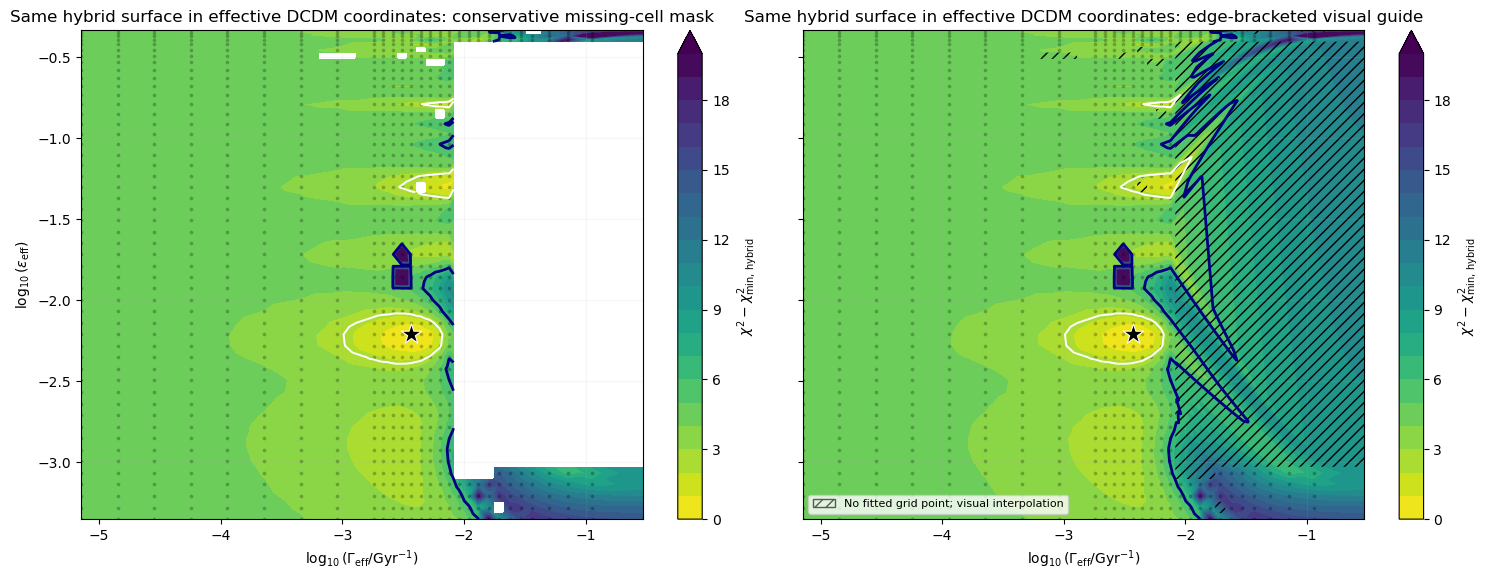

Sampled f_acc=1 points omitted from finite-Gamma plot: 9


In [8]:
epsilon_dense = epsilon_effective_from_log10_mass(x_dense)
gamma_dense = gamma_effective_from_log10_fraction(y_dense)
finite_gamma_rows = np.isfinite(gamma_dense) & (gamma_dense > 0)

log_gamma_dense = np.log10(gamma_dense[finite_gamma_rows])
log_epsilon_dense = np.log10(epsilon_dense[::-1])

def to_dcdm_orientation(surface):
    values = np.ma.asarray(surface)[finite_gamma_rows, ::-1]
    return values.T


delta_min_conservative_dcdm = to_dcdm_orientation(delta_min_conservative)
delta_min_bracketed_dcdm = to_dcdm_orientation(delta_min_bracketed)
unsupported_dcdm = unsupported[finite_gamma_rows, ::-1].T

point_log_epsilon, point_log_gamma = log10_effective_coordinates(
    completed["log10m_acc"], completed["log10f_acc"]
)
finite_point_transform = np.isfinite(point_log_epsilon) & np.isfinite(point_log_gamma)
best_log_epsilon, best_log_gamma = log10_effective_coordinates(
    np.asarray([best["log10m_acc"]]), np.asarray([best["log10f_acc"]])
)

fig_dcdm = draw_profile_pair(
    log_gamma_dense, log_epsilon_dense,
    delta_min_conservative_dcdm, delta_min_bracketed_dcdm, unsupported_dcdm,
    point_log_gamma[finite_point_transform], point_log_epsilon[finite_point_transform],
    float(best_log_gamma[0]), float(best_log_epsilon[0]),
    r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$",
    r"$\log_{10}(\epsilon_{\rm eff})$",
    "Same hybrid surface in effective DCDM coordinates",
)
plt.show()

omitted_infinite_rate = int((~np.isfinite(point_log_gamma)).sum())
print("Sampled f_acc=1 points omitted from finite-Gamma plot:", omitted_infinite_rate)



## Exclusion relative to LCDM in both coordinate systems



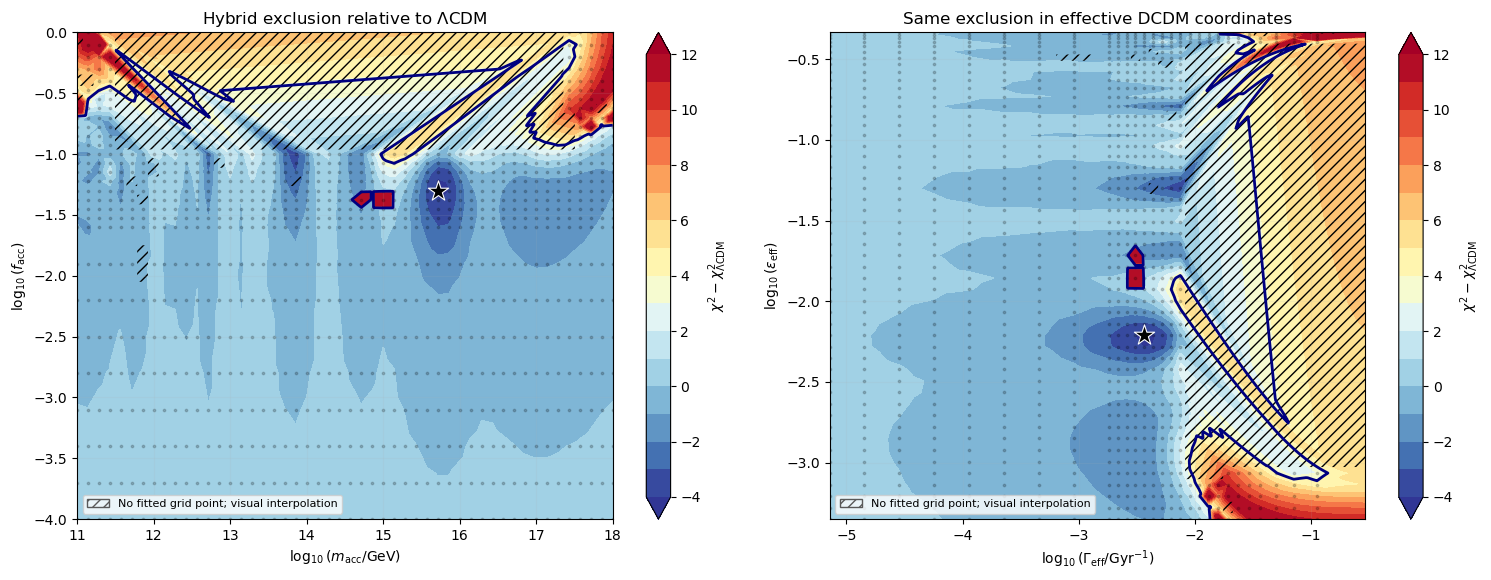

In [9]:
fig_exclusion, axes = plt.subplots(1, 2, figsize=(15.2, 5.9))

native_exclusion = axes[0].contourf(
    x_dense, y_dense, np.clip(delta_lcdm_bracketed, -4, 12),
    levels=np.linspace(-4, 12, 17), cmap="RdYlBu_r", extend="both",
)
axes[0].contour(
    x_dense, y_dense, delta_lcdm_bracketed,
    levels=[EXCLUSION_DELTA_CHI2], colors="navy", linewidths=2.0,
)
axes[0].contourf(
    x_dense, y_dense, unsupported.astype(float), levels=[0.5, 1.5],
    colors="none", hatches=["///"], alpha=0,
)
axes[0].scatter(
    completed["log10m_acc"], completed["log10f_acc"],
    s=3, color="black", alpha=0.18, rasterized=True,
)
axes[0].scatter(
    [best["log10m_acc"]], [best["log10f_acc"]], marker="*", s=235,
    color="black", edgecolor="white", linewidth=0.8, zorder=6,
)
axes[0].set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
axes[0].set_title(r"Hybrid exclusion relative to $\Lambda$CDM")
fig_exclusion.colorbar(
    native_exclusion, ax=axes[0], label=r"$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$",
)

delta_lcdm_dcdm = to_dcdm_orientation(delta_lcdm_bracketed)
dcdm_exclusion = axes[1].contourf(
    log_gamma_dense, log_epsilon_dense, np.clip(delta_lcdm_dcdm, -4, 12),
    levels=np.linspace(-4, 12, 17), cmap="RdYlBu_r", extend="both",
)
axes[1].contour(
    log_gamma_dense, log_epsilon_dense, delta_lcdm_dcdm,
    levels=[EXCLUSION_DELTA_CHI2], colors="navy", linewidths=2.0,
)
axes[1].contourf(
    log_gamma_dense, log_epsilon_dense, unsupported_dcdm.astype(float),
    levels=[0.5, 1.5], colors="none", hatches=["///"], alpha=0,
)
axes[1].scatter(
    point_log_gamma[finite_point_transform], point_log_epsilon[finite_point_transform],
    s=3, color="black", alpha=0.18, rasterized=True,
)
axes[1].scatter(
    [float(best_log_gamma[0])], [float(best_log_epsilon[0])], marker="*", s=235,
    color="black", edgecolor="white", linewidth=0.8, zorder=6,
)
axes[1].set_xlabel(r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$")
axes[1].set_ylabel(r"$\log_{10}(\epsilon_{\rm eff})$")
axes[1].set_title(r"Same exclusion in effective DCDM coordinates")
fig_exclusion.colorbar(
    dcdm_exclusion, ax=axes[1], label=r"$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$",
)

for axis in axes:
    axis.grid(alpha=0.12)
    axis.legend(
        handles=[Patch(facecolor="none", edgecolor="0.35", hatch="///",
                       label="No fitted grid point; visual interpolation")],
        loc="best", frameon=True, fontsize=8,
    )
fig_exclusion.tight_layout()
plt.show()



## Exploratory 95% boundary table

The boundary below is extracted from the **edge-bracketed visualization**,
not directly from a complete grid.  It is saved only as a refinement guide.



In [10]:
boundary_logf = np.full(len(x_dense), np.nan, dtype=float)
surface_values = delta_min_bracketed.filled(np.nan)
for column in range(len(x_dense)):
    good = np.flatnonzero(
        np.isfinite(surface_values[:, column])
        & (surface_values[:, column] <= DELTA_CHI2_95_2D)
    )
    if len(good):
        boundary_logf[column] = y_dense[good.max()]

boundary_table = pd.DataFrame({
    "log10m_acc": x_dense,
    "log10f_acc_95_visual": boundary_logf,
})
finite_boundary = np.isfinite(boundary_table["log10f_acc_95_visual"])
boundary_table.loc[finite_boundary, "f_acc_95_visual"] = (
    10.0 ** boundary_table.loc[finite_boundary, "log10f_acc_95_visual"]
)
boundary_table["epsilon_effective"] = epsilon_effective_from_log10_mass(
    boundary_table["log10m_acc"]
)
boundary_table.loc[finite_boundary, "gamma_effective_gyr_inverse"] = (
    gamma_effective_from_log10_fraction(
        boundary_table.loc[finite_boundary, "log10f_acc_95_visual"]
    )
)
print(boundary_table.loc[finite_boundary].iloc[::70].to_string(index=False))



 log10m_acc  log10f_acc_95_visual  f_acc_95_visual  epsilon_effective  gamma_effective_gyr_inverse
  11.000000             -0.701252         0.198952           0.464102                     0.015845
  11.701001             -0.744186         0.180225           0.355584                     0.014195
  12.402003             -0.701252         0.198952           0.214739                     0.015845
  13.103004             -0.644007         0.226983           0.111008                     0.018390
  13.804006             -0.758497         0.174382           0.053009                     0.013687
  14.505007             -0.722719         0.189357           0.024389                     0.014995
  15.206009             -0.686941         0.205617           0.011032                     0.016442
  15.907010             -0.536673         0.290621           0.004953                     0.024526
  16.608011             -0.522361         0.300358           0.002216                     0.025513
  17.30901

## Save products



In [11]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "hybrid_sampled_profile_likelihood.csv", index=False,
    )
    missing.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "hybrid_missing_expected_points.csv", index=False,
    )
    boundary_table.to_csv(
        OUTPUT_DIR / "hybrid_visual_95pct_boundary.csv", index=False,
    )
    summary = {
        "scope": "provisional_low_q1001_plus_completed_high_q5001",
        "expected_points": int(len(expected)),
        "completed_points": int(len(completed)),
        "missing_points": int(len(missing)),
        "low_q1001_points": int(len(low_fits)),
        "high_q5001_points": int(len(high_fits)),
        "lcdm_reference_chi2": float(LCDM_ONE_LOOP_CHI2),
        "effective_dcdm_mapping": {
            "t_reference_gyr": float(T_REFERENCE_GYR),
            "epsilon_definition": "momentum-matched two-body DCDM epsilon",
            "gamma_definition": "-ln(1-f_acc)/t_reference",
            "mapping_is_exact_model_equivalence": False,
        },
        "sampled_best_point": {
            "point_id": str(best.get("point_id", best["coordinate_key"])),
            "log10m_acc": float(best["log10m_acc"]),
            "log10f_acc": float(best["log10f_acc"]),
            "chi2_one_loop": float(best["chi2_one_loop"]),
            "delta_chi2_vs_lcdm": float(best["delta_chi2_vs_lcdm"]),
            "source_label": str(best["source_label"]),
            "momentum_bins": int(best["momentum_bins"]),
        },
        "warnings": [
            "high-f q=1001 scout fits are excluded",
            "missing high-f q=5001 cells remain missing in conservative maps",
            "hatched edge-bracketed surfaces are visualization-only",
            "effective DCDM coordinates are not an exact physical reparametrization",
            "final contours require targeted q=5001/q=10001 calculations",
        ],
    }
    (OUTPUT_DIR / "hybrid_analysis_summary.json").write_text(
        json.dumps(summary, indent=2, sort_keys=True) + "\n", encoding="utf-8",
    )
    fig_coverage.savefig(
        OUTPUT_DIR / "hybrid_sampled_likelihood_and_coverage.png",
        dpi=220, bbox_inches="tight",
    )
    fig_native.savefig(
        OUTPUT_DIR / "hybrid_profile_native_coordinates.png",
        dpi=220, bbox_inches="tight",
    )
    fig_dcdm.savefig(
        OUTPUT_DIR / "hybrid_profile_effective_dcdm_coordinates.png",
        dpi=220, bbox_inches="tight",
    )
    fig_exclusion.savefig(
        OUTPUT_DIR / "hybrid_exclusion_native_and_effective_dcdm.png",
        dpi=220, bbox_inches="tight",
    )
    print("Saved products to:", OUTPUT_DIR)



Saved products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_hybrid_q1001_q5001_v1


## Interpretation checklist

1. The discrete minimum and printed chi-square values use actual fits only.
2. No high-fraction q=1001 scout fit enters this hybrid likelihood.
3. White regions in conservative maps have no completed fit at the nearest
   expected coordinate.
4. Hatched regions are inferred only from edge anchors and must not be quoted
   as measured 68% or 95% confidence regions.
5. `epsilon_eff` matches the daughter recoil momentum, while `Gamma_eff`
   matches only the converted fraction at 14 Gyr; neither makes accDM and
   DCDM dynamically identical.
6. Use the maps to choose q=10001 anchors, then rebuild the final contours
   from the validated points.
